In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv('Housing.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [5]:
#observe the dataset and see what affects the pricing
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
#always check missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
#encoding categorical columns
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes':1,'no':0})

In [8]:
#one hot encoding for furnishingstatus
#This avoids multicollinearity 
df = pd.get_dummies(df,columns=['furnishingstatus'],drop_first=True)

In [9]:
#feature scaling , not needed in linear regression 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [11]:
#ed and visualization
#what factor affect pricing?
import seaborn as sns
import matplotlib.pyplot as pyplot

<Axes: xlabel='airconditioning', ylabel='price'>

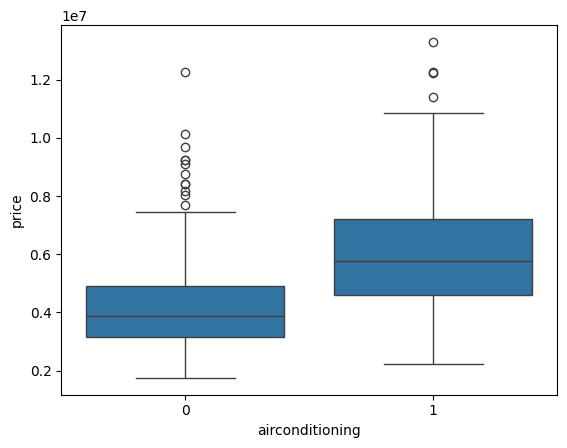

In [12]:
sns.boxplot(x='airconditioning',y='price',data=df)

In [13]:
#house with airconditioning have high price point


In [ ]:
#now split data and train model
#split:
X = df.drop('price',axis=1)
y = df['price']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
#scale - only train data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])


In [21]:
#train model:
model = LinearRegression()
model.fit(X_train,y_train)

importance = pd.Series(model.coef_, index=X.columns)
print(importance.sort_values(ascending = False))

airconditioning                    915769.291191
prefarea                           719916.280474
hotwaterheating                    697823.367872
area                               579406.225008
bathrooms                          498110.215136
basement                           467069.800182
mainroad                           427472.232936
stories                            394392.410989
parking                            238883.687449
guestroom                          221100.959167
bedrooms                           102596.393810
furnishingstatus_semi-furnished    -62631.662252
furnishingstatus_unfurnished      -385055.247346
dtype: float64


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 857981.1987297472
MSE: 1185641299795.43
RMSE: 1088871.5717638284
R2 Score: 0.5121384981734923


In [ ]:
#data leakage occured probably.